# NAME: FARHANKHAN PATHAN
# ROLL NO.: 61
# CLASS: CSAI_D-3



---






Q. 10. Assignment on Regression technique.

Download temperature data from the link below.

DATASET LINK :-https://www.kaggle.com/venky73/temperaturesof-india?select=temperatures.csv

This data consists of temperatures of INDIA averaging the temperatures of all places month wise. Temperatures values are recorded in CELSIUS






1.   Apply Linear Regression using a suitable library function and predict the Month-wise temperature.

2.   Assess the performance of regression models using MSE, MAE and R-Square

3.   Metrics

4.   Visualize a simple regression model.

1. Apply Linear Regression using a suitable library function and predict the Month-wise temperature.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("temperatures.csv")

print("First 5 Rows:\n")
print(df.head())

First 5 Rows:

   YEAR    JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP    OCT  \
0  1901  22.40  24.14  29.07  31.91  33.41  33.18  31.21  30.39  30.47  29.97   
1  1902  24.93  26.58  29.77  31.78  33.73  32.91  30.92  30.73  29.80  29.12   
2  1903  23.44  25.03  27.83  31.39  32.91  33.00  31.34  29.98  29.85  29.04   
3  1904  22.50  24.73  28.21  32.02  32.64  32.07  30.36  30.09  30.04  29.20   
4  1905  22.00  22.83  26.68  30.01  33.32  33.25  31.44  30.68  30.12  30.67   

     NOV    DEC  ANNUAL  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC  
0  27.31  24.49   28.96    23.27    31.46    31.27    27.25  
1  26.31  24.04   29.22    25.75    31.76    31.09    26.49  
2  26.08  23.65   28.47    24.24    30.71    30.92    26.26  
3  26.36  23.63   28.49    23.62    30.95    30.66    26.40  
4  27.52  23.82   28.30    22.25    30.00    31.33    26.57  


Convert the data from wide format into long format

In [5]:
long_df = df.melt(
    id_vars=["YEAR"],
    value_vars=["JAN","FEB","MAR","APR","MAY","JUN",
                "JUL","AUG","SEP","OCT","NOV","DEC"],
    var_name="Month",
    value_name="Temperature"
)
print(long_df.head())

   YEAR Month  Temperature
0  1901   JAN        22.40
1  1902   JAN        24.93
2  1903   JAN        23.44
3  1904   JAN        22.50
4  1905   JAN        22.00


In [6]:
month_map = {
    "JAN":1,"FEB":2,"MAR":3,"APR":4,"MAY":5,"JUN":6,
    "JUL":7,"AUG":8,"SEP":9,"OCT":10,"NOV":11,"DEC":12
}

long_df["Month"] = long_df["Month"].map(month_map)

In [7]:
print("\nTransformed Data:\n")
print(long_df.head())


Transformed Data:

   YEAR  Month  Temperature
0  1901      1        22.40
1  1902      1        24.93
2  1903      1        23.44
3  1904      1        22.50
4  1905      1        22.00



 2. Assess the performance of regression models using MSE, MAE and R-Square

In [10]:
X = long_df[["Month"]]
y = long_df["Temperature"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (1123, 1)
Testing Size: (281, 1)


In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


 3. Metrics

In [13]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [14]:
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 9.999806682283973


In [15]:
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 2.705271869781447


In [16]:
print("R-Square (R2 Score):", r2)

R-Square (R2 Score): -0.005573628993982727


4. Visualization

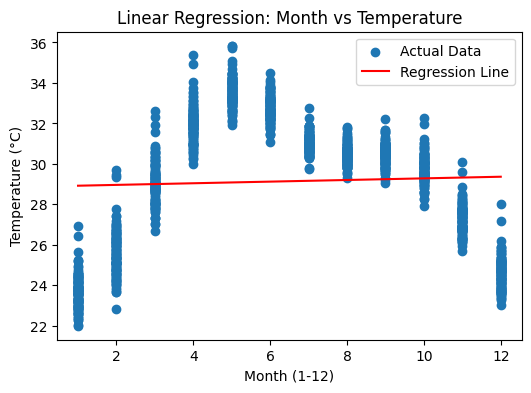

In [19]:
plt.figure(figsize=(6,4))

plt.scatter(X, y, label="Actual Data")

plt.plot(X, model.predict(X),color='red', label="Regression Line")

plt.xlabel("Month (1-12)")
plt.ylabel("Temperature (°C)")
plt.title("Linear Regression: Month vs Temperature")
plt.legend()

plt.show()